In [1]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

In [2]:
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from pyproj import Geod
from utils.plot import plot_available_buoys_two_events
from utils.swan_utils import mat_to_xr_dataset
geod = Geod(ellps='WGS84')
import matplotlib.pyplot as plt

* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


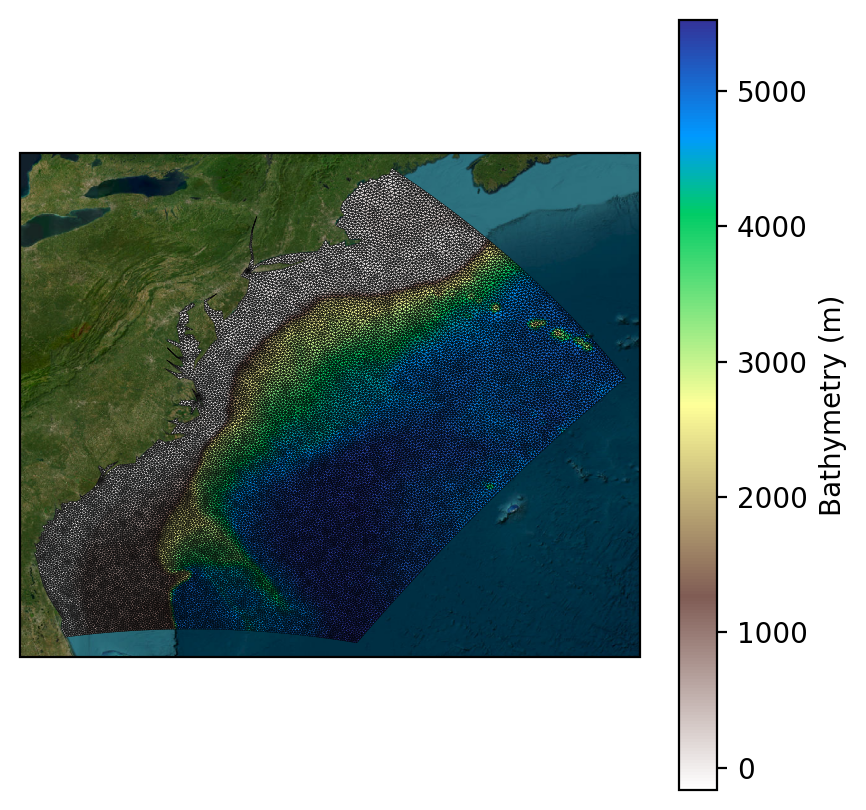

In [3]:
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
from utils.swan_utils import read_adcirc_grd

plot = DefaultStaticPlotting()
Nodes_calc, Elmts_calc, lines_calc = read_adcirc_grd("templates/fort.14")

facecolor = np.mean(Nodes_calc[:, 3][Elmts_calc[:, 2:5].astype(int)], axis=1)

fig, ax = plot.get_subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(5, 5),
)

pcl = ax.tripcolor(
    Nodes_calc[:, 1],
    Nodes_calc[:, 2],
    Elmts_calc[:, 2:5],
    facecolor,
    edgecolors="k",
    linewidth=0.2,
    shading="flat",
    cmap="terrain_r",
)
colorbar = fig.colorbar(pcl, ax=ax, orientation="vertical")
colorbar.set_label("Bathymetry (m)")
margim = 0.5
plot.plot_satellite(
        ax=ax,
        source="arcgis",
        area=[
            Nodes_calc[:, 1].min() - margim,
            Nodes_calc[:, 1].max() + margim,
            Nodes_calc[:, 2].min() - margim,
            Nodes_calc[:, 2].max() + margim,
        ],)

In [4]:
dm = 16384

lon_min = Nodes_calc[:, 1].min()
lon_max = Nodes_calc[:, 1].max()
lat_min = Nodes_calc[:, 2].min()
lat_max = Nodes_calc[:, 2].max()

lat_ref = 0.5 * (lat_min + lat_max)

min_dy = dm / 111320.0
min_dx = dm / (111320.0 * np.cos(np.deg2rad(lat_ref)))

lon_grid = np.arange(lon_min, lon_max + min_dx, min_dx)
lat_grid = np.arange(lat_min, lat_max + min_dy, min_dy)

dlon = lon_grid[1] - lon_grid[0]
dlat = lat_grid[1] - lat_grid[0]
nx = len(lon_grid) - 1
ny = len(lat_grid) - 1

In [5]:
Tracks = xr.open_dataset("outputs/hist_tracks_7r.nc")
Tracks

<xarray.Dataset> Size: 1MB
Dimensions:  (storm: 172, time: 289)
Coordinates:
  * storm    (storm) <U14 10kB 'GERT_1981' 'UNNAMED_1981' ... 'WANDA_2021'
  * time     (time) int64 2kB 0 1 2 3 4 5 6 7 ... 282 283 284 285 286 287 288
    date     (storm) <U19 13kB ...
Data variables:
    lat      (storm, time) float64 398kB ...
    lon      (storm, time) float64 398kB ...
    pmin     (storm, time) float64 398kB ...
Attributes:
    description:  Historic TC tracks

In [6]:
names_to_find = ['FLORENCE_2018', 'IRENE_2011', 'MATTHEW_2016']

storm_names = np.array([s.decode('utf-8') if isinstance(s, bytes) else s for s in Tracks.storm.values])

selected_cases = [i for i, name in enumerate(storm_names) if name in names_to_find]

print(Tracks.storm.values[selected_cases])
print(selected_cases)

['IRENE_2011' 'MATTHEW_2016' 'FLORENCE_2018']
[114, 135, 145]


In [7]:
from utils.CarolinasParamWrapper_swan import CarolinasParaMWrapper

templates_dir = "templates"
output_dir_param =  "cases/historical_param"

time_step = 1 # hours

fixed_parameters = {
    "time_step": 3600 * time_step,
    "time_step_comp":900,
    "lon_grid":lon_grid,
    "lat_grid":lat_grid,
    "lon_min":lon_min,
    "lat_min":lat_min,
    "Tracks":Tracks,
    "dlon":dlon,
    "dlat":dlat,
    "nx":nx,
    "ny":ny,
    "additional_time":20 * 60 * 60,
}

metamodel_parameters = {
    "index": selected_cases,
}

swan_wrapper_param = CarolinasParaMWrapper(
    templates_dir=templates_dir,
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=output_dir_param,
)

#swan_wrapper_param.build_cases(mode="one_by_one", cases_name_format=lambda ctx: f"{Tracks.storm.values[ctx.get('index')]}")

2026-01-19 09:37:29,900 - CarolinasParaMWrapper - WARNING - Parameter index is not in the default_parameters


In [8]:
import xarray as xr
from bluemath_tk.tcs.tracks import (
    historic_track_interpolation,
    historic_track_preprocessing,
)
from bluemath_tk.tcs.vortex import vortex_model_grid


p_tracks = "https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/IBTrACS.ALL.v04r00.nc"
xds_tcs = xr.open_dataset(p_tracks)

xds_vortex = []
names = []

for name in names_to_find:
    name_tc, year_tc = name.split("_")
    year_tc = int(year_tc)
    names.append(name)
    itc = np.where(
        (xds_tcs["name"].values.astype("str") == name_tc)
        & (xds_tcs.isel(date_time=0).time.dt.year.values == year_tc)
    )[0]
    storm = xds_tcs.isel(storm=itc).squeeze().load()

    centerID = "USA"
    df_TC_hist = historic_track_preprocessing(xds=storm, center=centerID)

    storm_track, time_input = historic_track_interpolation(df=df_TC_hist, dt_comp=time_step * 60)

    xds_vortex_GS = vortex_model_grid(
        storm_track=storm_track,
        cg_lon=lon_grid,
        cg_lat=lat_grid,
        coords_mode="SPHERICAL",
    )
    xds_vortex_GS = xds_vortex_GS.transpose("time", "lon", "lat")
    xds_vortex.append(xds_vortex_GS)


In [9]:
from utils.CarolinasDynamicWrapper_swan import CarolinasDynamicMWrapper

output_dir_hist =  "cases/historical_dynamic"

fixed_parameters = {
    "time_step": 3600 * time_step,
    "time_step_comp":900,
    "additional_time":20 * 60 * 60,
    "dlon":dlon,
    "dlat":dlat,
    "lon_min":lon_min,
    "lat_min":lat_min,
    "nx":nx,
    "ny":ny,
}

metamodel_parameters = {
    "xds_vortex_GS": xds_vortex,
    "name": names,
}

swan_wrapper_dynamic = CarolinasDynamicMWrapper(
    templates_dir=templates_dir,
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=output_dir_hist,
)

#swan_wrapper_dynamic.build_cases(mode="one_by_one", cases_name_format=lambda ctx: f"{ctx.get('name')}")

2026-01-19 09:37:44,388 - CarolinasDynamicMWrapper - WARNING - Parameter xds_vortex_GS is not in the default_parameters
2026-01-19 09:37:44,388 - CarolinasDynamicMWrapper - WARNING - Parameter name is not in the default_parameters


In [15]:
for name in names_to_find:

    mat_p = mat_to_xr_dataset(
        f"{output_dir_param}/{name}/output.mat"
    )
    mat = mat_to_xr_dataset(
        f"{output_dir_hist}/{name}/output.mat"
    )

    plot_available_buoys_two_events(
        event_name=name,
        ds_parametrized=mat_p,
        ds_historic=mat,
        csv_path='outputs/hist_tracks_7r_params.csv',
        nc_path='/lustre/geocean/WORK/users/Pablo/MUSCLE_TCS_NC/outputs/tracks_at_7r/hist_tracks_7r_filter.nc',
        data_dir='inputs/buoy_data/',
    )
    out_path = f"figures/02_{name}_buoys.png"
    
fig_counter = 0

for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig.savefig(
        f"figures/Syntesis/02_{fig_num}_buoys.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(fig)
    fig_counter += 1

2018-09-12 15:00:00
2011-08-26 07:00:00
2016-10-07 23:00:00
